In [15]:
from simfile import SimFile
from simulation import Simulation
from validation import switchOffAllEffects, fitOneOverF2
import os
import numpy as np
import matplotlib.pyplot as plt
import math
import h5py
import h5

When we change only the yaw or only the pitch, it is as if the star describes a circle, similar to a parallel in the figure below on the left-hand side, around the considered axis (yaw or pitch).  Projecting this onto the CCD is then similar to projecting the parallels to the lines that are more or less horizontal on the plot below on the right-hand side.  If the circle of the parallel is small (i.e. when you are further away from the considered axis), the projected line diverges more and more from the projected equator.

![title](gnomonicProjection.gif)

In [24]:
sim = Simulation("TED")
switchOffAllEffects(sim)
sim["ObservingParameters/NumExposures"] = 1
sim.outputDir = os.environ["PLATO_WORKDIR"]

starCatalogFilename = os.environ["PLATO_WORKDIR"] + "generatedFromPixelCoordinates.starcat"

position = 1000
dimColumn = 100
dimRow = 4510
# sim["SubField/SubPixels"] = 1
numSubPixels = sim["SubField/SubPixels"]

sim.createStarCatalogFileFromPixelCoordinates(np.array([0]), np.array([position]), np.array([12.5]), np.array([1]), starCatalogFilename)
sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename

sim["SubField/NumRows"] = dimRow
sim["SubField/NumColumns"] = dimColumn
sim["SubField/ZeroPointRow"] = 0 #- dimRow // 2
sim["SubField/ZeroPointColumn"] = position #- dimColumn // 2
    

sim["PSF/Model"] = "MappedGaussian"
sim["CCD/IncludeConvolution"] = "no"

sim["Telescope/UseDrift"] = "yes"
sim["Telescope/UseDriftFromFile"] = "yes"

sim["ObservingParameters/CycleTime"] = sim.getReadoutTime()[0] + 1

In [25]:
driftTimeScale = 0.1
drift = -50

numDriftSteps = int(25 / driftTimeScale) * 500
time = np.arange(numDriftSteps) * driftTimeScale
noChange = np.zeros(numDriftSteps)
change = np.arange(numDriftSteps) * drift

driftFilenameYaw = os.environ["PLATO_WORKDIR"] + "yawDrift.txt"
driftFilenamePitch = os.environ["PLATO_WORKDIR"] + "pitchDrift.txt"
driftFilenameRoll = os.environ["PLATO_WORKDIR"] + "rollDrift.txt"

np.savetxt(driftFilenameYaw, np.c_[time, change, noChange, noChange])
np.savetxt(driftFilenamePitch, np.c_[time, noChange, change, noChange])
np.savetxt(driftFilenameRoll, np.c_[time, noChange, noChange, change])

sim["ControlHDF5Content/WriteStarPositions"] = "yes"

In [29]:
drift2 = drift / 10 * 250

driftTimeScale2 = 0.1 * 250 #25
numDriftSteps2 = int(25 / driftTimeScale2) * 500
time2 = np.arange(numDriftSteps2) * driftTimeScale2
noChange2 = np.zeros(numDriftSteps2)
change2 = np.arange(numDriftSteps2) * drift2

driftFilenameYaw2 = os.environ["PLATO_WORKDIR"] + "yawDrift2.txt"
driftFilenamePitch2 = os.environ["PLATO_WORKDIR"] + "pitchDrift2.txt"
driftFilenameRoll2 = os.environ["PLATO_WORKDIR"] + "rollDrift2.txt"

np.savetxt(driftFilenameYaw2, np.c_[time2, change2, noChange2, noChange2])
np.savetxt(driftFilenamePitch2, np.c_[time2, noChange2, change2, noChange2])
np.savetxt(driftFilenameRoll2, np.c_[time2, noChange2, noChange2, change2])

In [30]:
print("Test")

Test


# Change in yaw only (exaggerated)

Yaw
500


Error: SimfFile.getStarCoordinates(): Exposure000059 not in hdf5 file
[0.02252428 0.04579302 0.06980639 0.09456456 0.12006774 0.14631609
 0.17330983 0.20104915 0.22953425 0.25876535 0.28874267 0.31946642
 0.35093685 0.38315418 0.41611864 0.4498305  0.48429    0.51949739
 0.55545294 0.59215692 0.62960959 0.66781125 0.70676217 0.74646264
 0.78691297 0.82811345 0.87006438 0.9127661  0.9562189  1.00042312
 1.04537909 1.09108714 1.13754761 1.18476086 1.23272723 1.28144709
 1.33092079 1.38114871 1.43213123 1.48386872 1.53636157 1.58961018
 1.64361494 1.69837627 1.75389456 1.81017024 1.86720373 1.92499546
 1.98354585 2.04285535 2.10292441 2.16375347 2.225343   2.28769345
 2.35080529 2.414679   2.47931506 2.54471396 2.61087618]
1500


Error: SimfFile.getStarCoordinates(): Exposure000059 not in hdf5 file
[ 0.2005092   0.40329988  0.60837359  0.81573186  1.02537626  1.23730836
  1.45152978  1.66804211  1.88684701  2.10794611  2.33134109  2.55703364
  2.78502547  3.01531829  3.24791385 

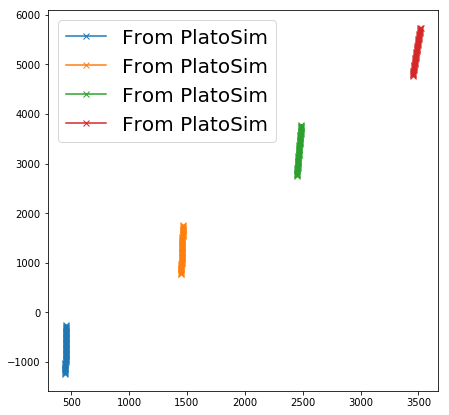

In [31]:
# sim["Telescope/DriftFileName"] = driftFilenameYaw
sim["Telescope/DriftFileName"] = driftFilenameYaw2

numExposures = 60
sim["ObservingParameters/NumExposures"] = numExposures

# output = sim.run(removeOutputFile = True)

fig = plt.figure(figsize = (7, 7))
ax = fig.add_subplot(1, 1, 1)

print("Yaw")

for position in np.arange(500, 4500, 1000):
    
    print(position)
    
    sim.createStarCatalogFileFromPixelCoordinates(np.array([position]), np.array([position]), np.array([12.5]), np.array([1]), starCatalogFilename)
    sim["ObservingParameters/StarCatalogFile"] = starCatalogFilename
    
    sim["SubField/ZeroPointRow"] = 0 #- dimRow // 2
    sim["SubField/ZeroPointColumn"] = position #- dimColumn // 2
    
    output = sim.run(removeOutputFile = True)
    
    rows = np.array([])
    columns = np.array([])

    for exposure in range(numExposures):
        try:
            ([row], [column]) = output.getStarCoordinates(exposure)[1:3]
            rows = np.append(rows, row)
            columns = np.append(columns, column)
        except:
            break
    
        
#     plt.plot(columns, rows, marker="x", label=position)
    plt.plot(columns + position - dimColumn // 2, rows + position - dimRow // 2, marker="x", label = "From PlatoSim")
    
    print(columns)
    
plt.legend(loc='best', fontsize = 20)

In [ ]:
fig = plt.figure(figsize = (7, 7))
ax = fig.add_subplot(1, 1, 1)

sim["Telescope/DriftFileName"] = driftFilenameYaw

numExposures = 1
sim["ObservingParameters/NumExposures"] = numExposures
sim["ObservingParameters/CycleTime"] = 25

output = sim.run(removeOutputFile = True)

im = output.getImage(0)
plt.imshow(im, origin = "lower", cmap='gray', vmin = 5800, vmax = 6100)

In [187]:
sim["Telescope/DriftFileName"] = driftFilenameYaw2

numExposures = 10
sim["ObservingParameters/NumExposures"] = numExposures

sim["SubField/NumRows"] = dimRow
sim["SubField/NumColumns"] = dimColumn
sim["SubField/ZeroPointRow"] = position #- dimRow // 2
sim["SubField/ZeroPointColumn"] = position #- dimColumn // 2

output = sim.run(removeOutputFile = True)

Text(0, 0.5, '$y_{CCD} [pixels]$')

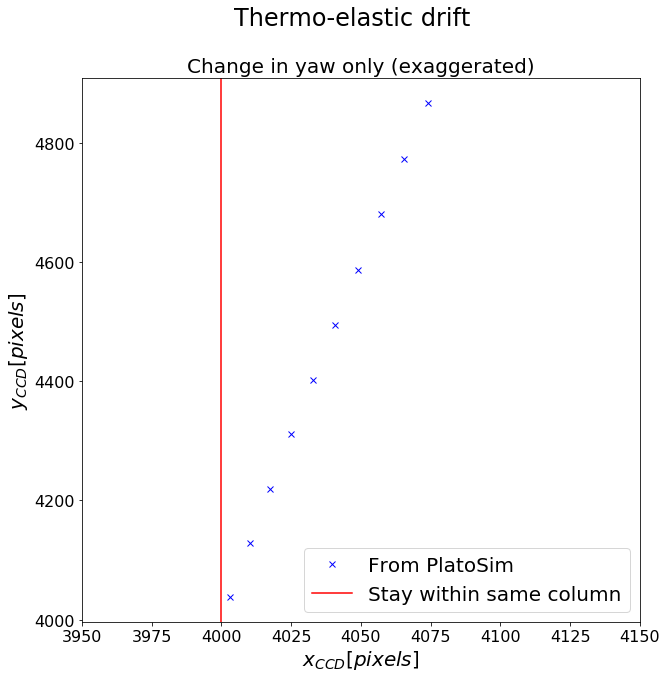

In [195]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)


###############
# From PlatoSim
###############

rows = np.array([])
columns = np.array([])

for exposure in range(numExposures):
    try:
        ([row], [column]) = output.getStarCoordinates(exposure)[1:3]
        rows = np.append(rows, row)
        columns = np.append(columns, column)
    except:
        break

plt.plot(columns + position, rows + position, "bx", label = "From PlatoSim")


    
    
###############
# Change in row
###############

plt.axvline(x = dim / 2 + position - dim // 2, color = "r", label = "Stay within same column")



########
# Layout
########

plt.xlim([position - 50, position + 150])
# plt.ylim([position - 50, position + 150])

plt.suptitle("Thermo-elastic drift", fontsize = 24)
plt.title("Change in yaw only (exaggerated)", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("$x_{CCD} [pixels]$", fontsize = 20)
plt.ylabel("$y_{CCD} [pixels]$", fontsize = 20)

# Change in pitch only (exaggerated)

Fast camera: 0CCD position: CustomReadout mode: Nominal0 * 0.000090
4540 *  (2285 * 0.000000 + 0.000110)




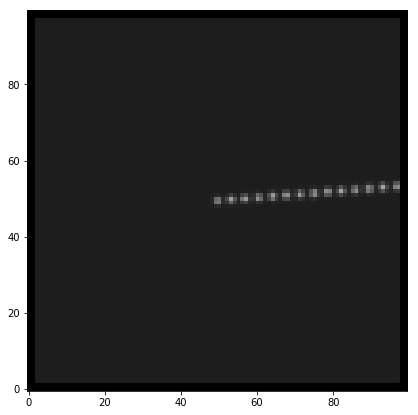

In [16]:
fig = plt.figure(figsize = (7, 7))
ax = fig.add_subplot(1, 1, 1)

sim["Telescope/DriftFileName"] = driftFilenamePitch

numExposures = 1
sim["ObservingParameters/NumExposures"] = numExposures
output = sim.run(removeOutputFile = True)

im = output.getImage(0)
plt.imshow(im, origin = "lower", cmap='gray', vmin = 5800, vmax = 6100)

In [17]:
sim["Telescope/DriftFileName"] = driftFilenamePitch2

numExposures = 100
sim["ObservingParameters/NumExposures"] = numExposures

output = sim.run(removeOutputFile = True)

Fast camera: 0CCD position: CustomReadout mode: Nominal0 * 0.000090
4540 *  (2285 * 0.000000 + 0.000110)




Error: SimfFile.getStarCoordinates(): Exposure000014 not in hdf5 file


Text(0, 0.5, '$y_{CCD} [pixels]$')

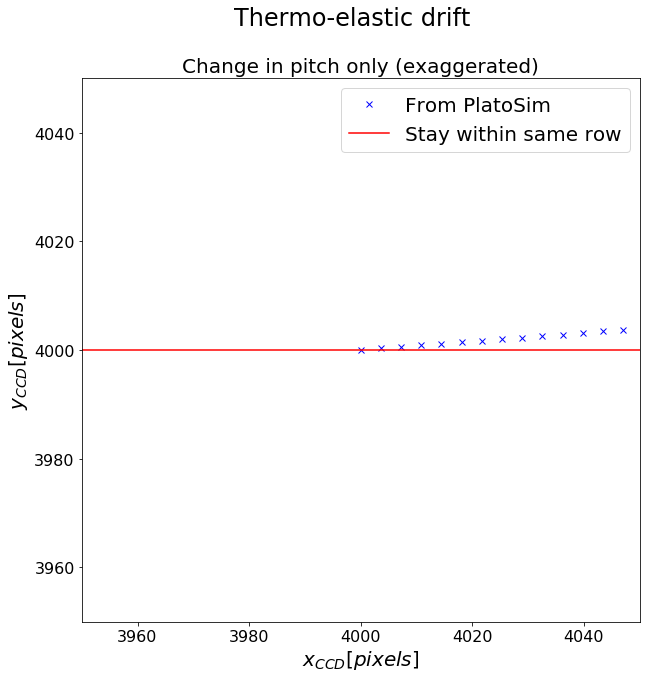

In [18]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

rows = np.array([])
columns = np.array([])

for exposure in range(numExposures):
    try:
        ([row], [column]) = output.getStarCoordinates(exposure)[1:3]
        rows = np.append(rows, row)
        columns = np.append(columns, column)
    except:
        break

plt.plot(columns + position - dim // 2, rows + position - dim // 2, "bx", label = "From PlatoSim")



##################
# Change in column
##################

plt.axhline(y = dim / 2 + position - dim // 2, color = "r", label = "Stay within same row")

    
    
########
# Layout
########

plt.xlim([position - 50, position + 50])
plt.ylim([position - 50, position + 50])

plt.suptitle("Thermo-elastic drift", fontsize = 24)
plt.title("Change in pitch only (exaggerated)", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("$x_{CCD} [pixels]$", fontsize = 20)
plt.ylabel("$y_{CCD} [pixels]$", fontsize = 20)

# Change in roll only (exaggerated)

Fast camera: 0CCD position: CustomReadout mode: Nominal0 * 0.000090
4540 *  (2285 * 0.000000 + 0.000110)




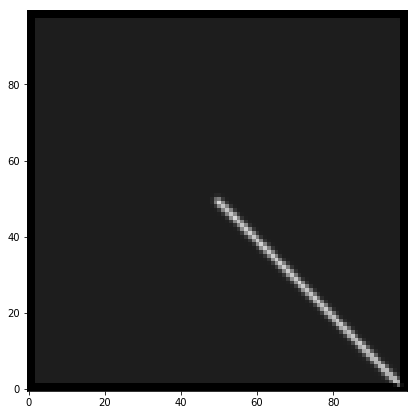

In [19]:
fig = plt.figure(figsize = (7, 7))
ax = fig.add_subplot(1, 1, 1)

sim["Telescope/DriftFileName"] = driftFilenameRoll

numExposures = 1
sim["ObservingParameters/NumExposures"] = numExposures
output = sim.run(removeOutputFile = True)

im = output.getImage(0)
plt.imshow(im, origin = "lower", cmap='gray', vmin = 5800, vmax = 6100)

In [20]:
sim["Telescope/DriftFileName"] = driftFilenameRoll2

numExposures = 100
sim["ObservingParameters/NumExposures"] = numExposures

output = sim.run(removeOutputFile = True)

Fast camera: 0CCD position: CustomReadout mode: Nominal0 * 0.000090
4540 *  (2285 * 0.000000 + 0.000110)




Text(0, 0.5, '$y_{CCD} [pixels]$')

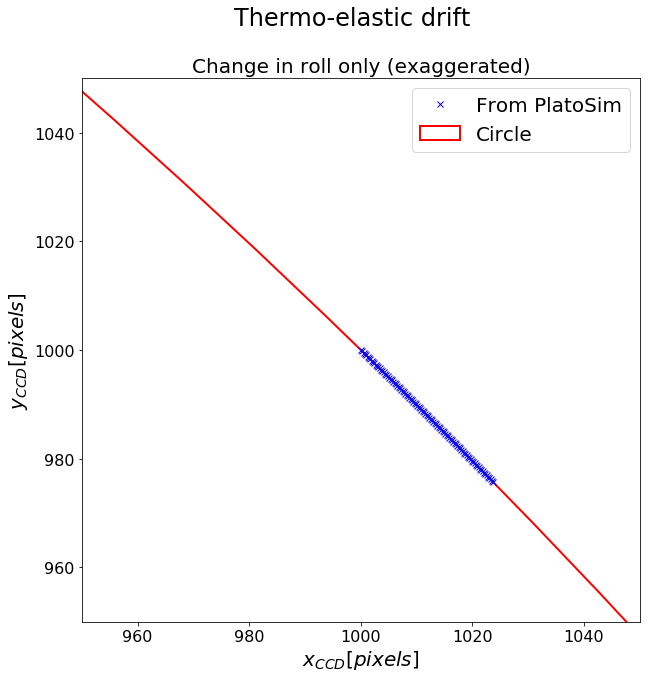

In [23]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

rows = np.array([])
columns = np.array([])

for exposure in range(numExposures):
    try:
        ([row], [column]) = output.getStarCoordinates(exposure)[1:3]
        rows = np.append(rows, row)
        columns = np.append(columns, column)
    except:
        break

plt.plot(columns + position - dim // 2, rows + position - dim // 2, "bx", label = "From PlatoSim")



##################
# Change in column
##################

radiusSquared = 2 * (position**2)
circ = plt.Circle((0,0), radius = math.sqrt(radiusSquared), color = "white", linewidth = 2, label = "Circle")
ax.add_patch(circ)
circ.set_edgecolor("r")
circ.set_facecolor("none")

    
    
########
# Layout
########

plt.xlim([position - 50, position + 50])
plt.ylim([position - 50, position + 50])

plt.suptitle("Thermo-elastic drift", fontsize = 24)
plt.title("Change in roll only (exaggerated)", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("$x_{CCD} [pixels]$", fontsize = 20)
plt.ylabel("$y_{CCD} [pixels]$", fontsize = 20)

# Auto-generated TED

In [49]:
sim["Telescope/UseDriftFromFile"] = "no"

rmsYaw = 2.0
rmsPitch = 3.0
rmsRoll = 4.0

sim["Telescope/DriftYawRms"] = rmsYaw
sim["Telescope/DriftPitchRms"] = rmsPitch
sim["Telescope/DriftRollRms"] = rmsRoll

sim["SubField/NumRows"] = 1
sim["SubField/NumColumns"] = 1

numExposures = 10000
sim["ObservingParameters/NumExposures"] = numExposures
output = sim.run(removeOutputFile = True)

print("Done")


2019-05-29 17:58:58 WARNING Simulation: no information about detected stars to write to HDF5
2019-05-29 17:58:58 WARNING Camera: No star positions to write to HDF5 file.

Done


In [50]:
hfile = h5py.File(os.environ["PLATO_WORKDIR"] + "TED.hdf5", 'r')

yaw = h5.h5get(hfile, ["Telescope", "TelescopeYaw"], verbose = True)
pitch = h5.h5get(hfile, ["Telescope", "TelescopePitch"], verbose = True)
roll = h5.h5get(hfile, ["Telescope", "TelescopeRoll"], verbose = True)

selection strings: ['Telescope', 'TelescopeYaw']
matching items:
    Dataset         /Telescope/TelescopeYaw
selection strings: ['Telescope', 'TelescopePitch']
matching items:
    Dataset         /Telescope/TelescopePitch
selection strings: ['Telescope', 'TelescopeRoll']
matching items:
    Dataset         /Telescope/TelescopeRoll


In [51]:
hfile = h5py.File(os.environ["PLATO_WORKDIR"] + "TED.hdf5", 'r')
time = h5.h5get(hfile, ["ACS", "Time"], verbose = True)

selection strings: ['ACS', 'Time']
matching items:
    Dataset         /ACS/Time


In [52]:
print("Timescale for TED:", sim["Telescope/DriftTimeScale"], "s")

Timescale for TED: 86400.0 s


### Yaw

Text(0, 0.5, 'Yaw [degrees]')

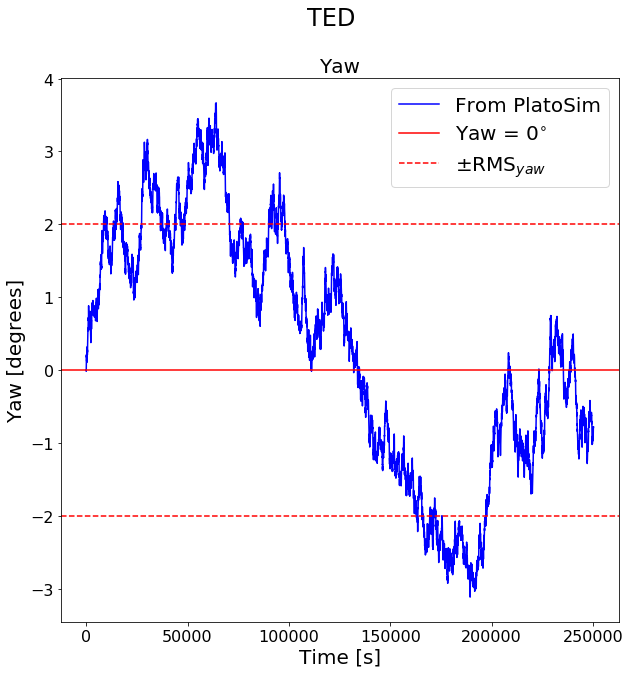

In [77]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

plt.plot(time, yaw, "b", label = "From PlatoSim")



#################
# Average of zero
#################

plt.axhline(y = 0, color = "r", label = "Yaw = 0$^{\circ}$")
plt.axhline(y = 0 - yawRms, color = "r", linestyle = "dashed", label = "$\\pm$RMS$_{yaw}$")
plt.axhline(y = 0 + yawRms, color = "r", linestyle = "dashed")



########
# Layout
########

plt.suptitle("TED", fontsize = 24)
plt.title("Yaw", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Time [s]", fontsize = 20)
plt.ylabel("Yaw [degrees]", fontsize = 20)

[ 3.29978055e+03+0.00000000e+00j  1.37957818e+03-1.11367387e+04j
  8.65715488e+02+1.25374821e+02j ... -2.20868525e+00+1.22868558e-01j
  4.45734734e+00+3.98284777e+00j  1.85827448e+00-1.23781026e+00j]


Text(0, 0.5, 'PSD')

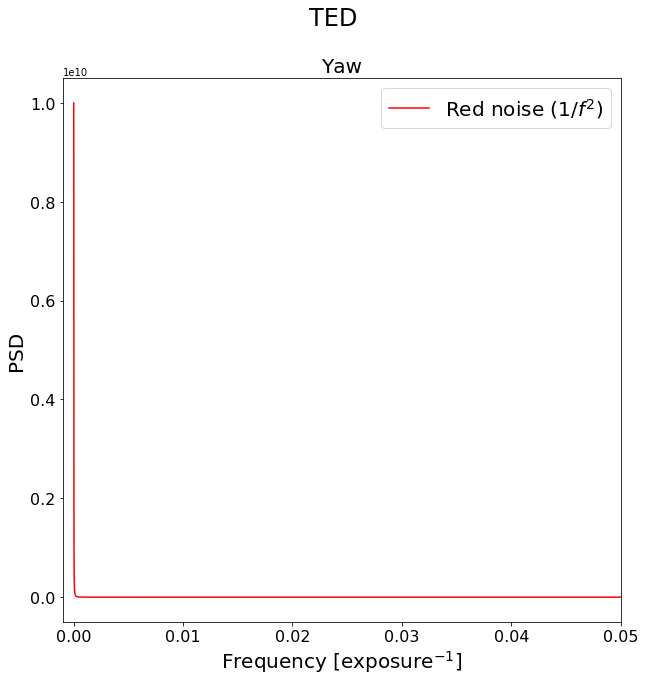

In [81]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

fs = 1
xF = np.fft.fft(yaw)     # Fast Fourier transform of the yaw time series
N = len(xF)
xF = xF[0:int(N//2)]
fr = np.linspace(0,fs/2,int(N//2))

# plt.plot(fr, abs(xF)**2, "b", label = "From PlatoSim")

print(xF)



###########
# Red noise
###########

frNonZero = fr[fr != 0]
redNoise = 1 / frNonZero**2

plt.plot(frNonZero, redNoise, "r", label = "Red noise ($1 / f^2)$")



########
# Layout
########

plt.xlim([-0.001, 0.05])
# plt.ylim([0, 10000000])

plt.suptitle("TED", fontsize = 24)
plt.title("Yaw", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Frequency [exposure$^{-1}$]", fontsize = 20)
plt.ylabel("PSD", fontsize = 20)

4999


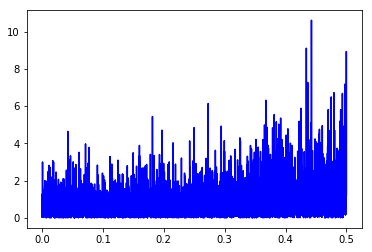

In [44]:
plt.plot(fr[1:], (abs(xF[1:])**2) / redNoise, "b", label = "From PlatoSim")
abs(xF[1:])**2
print(len(redNoise))

In [32]:
print(xF**2)

[ 1.08885517e+07+0.00000000e+00j -1.22123713e+08-3.07280035e+07j
  7.33744461e+05+2.17077849e+05j ...  4.86319384e+00-5.42755942e-01j
  4.00486895e+00+3.55058719e+01j  1.92100982e+00-4.60038243e+00j]


### Pitch

Text(0, 0.5, 'Pitch [degrees]')

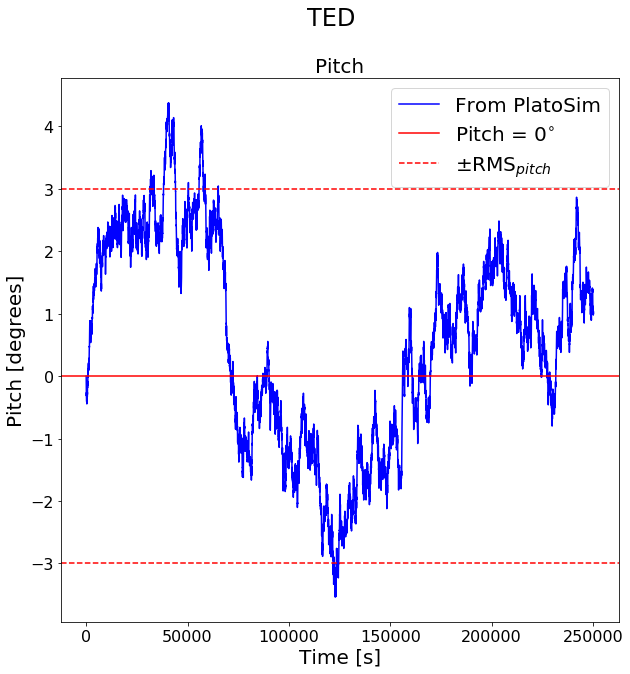

In [55]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

ax = fig.add_subplot(1, 1, 1)
plt.plot(time, pitch, "b", label = "From PlatoSim")



#################
# Average of zero
#################

plt.axhline(y = 0, color = "r", label = "Pitch = 0$^{\circ}$")
plt.axhline(y = 0 - pitchRms, color = "r", linestyle = "dashed", label = "$\\pm$RMS$_{pitch}$")
plt.axhline(y = 0 + pitchRms, color = "r", linestyle = "dashed")



########
# Layout
########

plt.suptitle("TED", fontsize = 24)
plt.title("Pitch", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Time [s]", fontsize = 20)
plt.ylabel("Pitch [degrees]", fontsize = 20)

Text(0, 0.5, 'PSD')

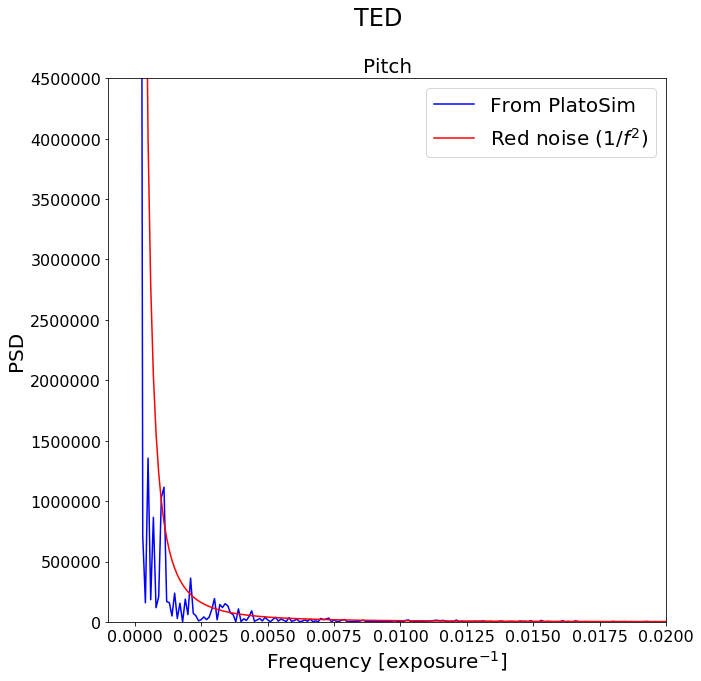

In [19]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

fs = 1
xF = np.fft.fft(pitch)
N = len(xF)
xF = xF[0:int(N//2)]
fr = np.linspace(0,fs/2,int(N//2))

plt.plot(fr, abs(xF)**2, "b", label = "From PlatoSim")



###########
# Red noise
###########

frNonZero = fr[fr != 0]
redNoise = 1 / frNonZero**2

plt.plot(frNonZero, redNoise, "r", label = "Red noise ($1 / f^2)$")



########
# Layout
########

plt.xlim([-0.001, 0.02])
plt.ylim([0, 4500000])

plt.suptitle("TED", fontsize = 24)
plt.title("Pitch", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Frequency [exposure$^{-1}$]", fontsize = 20)
plt.ylabel("PSD", fontsize = 20)

### Roll

Text(0, 0.5, 'Roll [degrees]')

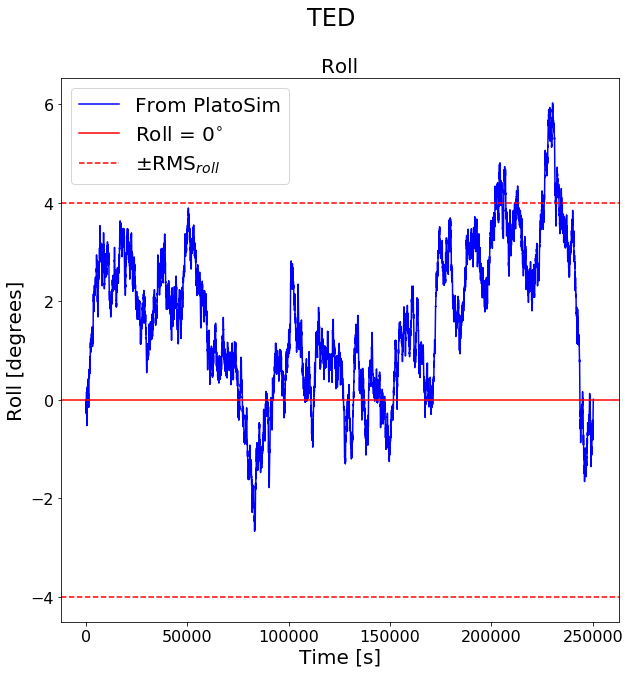

In [56]:
fig = plt.figure(figsize = (10, 10))



###############
# From PlatoSim
###############

ax = fig.add_subplot(1, 1, 1)
plt.plot(time, roll, "b", label = "From PlatoSim")



#################
# Average of zero
#################

plt.axhline(y = 0, color = "r", label = "Roll = 0$^{\circ}$")
plt.axhline(y = 0 - rollRms, color = "r", linestyle = "dashed", label = "$\\pm$RMS$_{roll}$")
plt.axhline(y = 0 + rollRms, color = "r", linestyle = "dashed")



########
# Layout
########

plt.suptitle("TED", fontsize = 24)
plt.title("Roll", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Time [s]", fontsize = 20)
plt.ylabel("Roll [degrees]", fontsize = 20)

Text(0, 0.5, 'PSD')

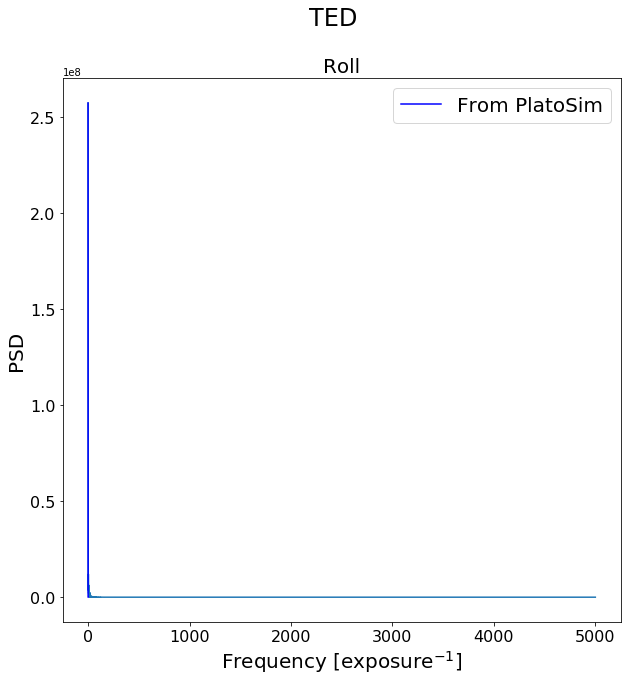

In [85]:
fig = plt.figure(figsize = (10, 10))
ax = fig.add_subplot(1, 1, 1)



###############
# From PlatoSim
###############

fs = 1
xF = np.fft.fft(roll)
N = len(xF)
xF = xF[0:int(N//2)]
fr = np.linspace(0,fs/2,int(N//2))
plt.plot(abs(xF)**2)

plt.plot(fr, abs(xF)**2, "b", label = "From PlatoSim")



###########
# Red noise
###########

frNonZero = fr[fr != 0]
redNoise = 1 / frNonZero**2

# plt.plot(frNonZero, redNoise, "r", label = "Red noise ($1 / f^2)$")



########
# Layout
########

# plt.xlim([-0.001, 0.02])
# plt.ylim([0, 15000000])

plt.suptitle("TED", fontsize = 24)
plt.title("Roll", fontsize = 20)
plt.legend(loc='best', fontsize = 20)

for tick in ax.xaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
for tick in ax.yaxis.get_major_ticks():
    tick.label.set_fontsize(16)
    
plt.xlabel("Frequency [exposure$^{-1}$]", fontsize = 20)
plt.ylabel("PSD", fontsize = 20)

In [57]:
def rednoiseModel(freq, tau, sigma):

    """
    PURPOSE: compute the mean power spectral density (PSD) corresponding to the red noise
             time series that is generated by a red noise model (random walk).

    INPUT: freq:       frequency points of the PSD  [microHz | mHz | Hz]
           tau:  time scale of the red noise
           sigma:   variation scale

    OUTPUT: psd:  power spectral density   [ppm^2/microHz | ppm^2/microHz | ppm^2/microHz]
    """

    psd = sigma * sigma * tau / (1.0 + (2.0*np.pi*freq*tau)**2)
    
    return psd

In [66]:
redNoise = rednoiseModel(fr,  sim["Telescope/DriftTimeScale"] / 25., rmsYaw)

In [82]:
np.fft.fft.__doc__

'\n    Compute the one-dimensional discrete Fourier Transform.\n\n    This function computes the one-dimensional *n*-point discrete Fourier\n    Transform (DFT) with the efficient Fast Fourier Transform (FFT)\n    algorithm [CT].\n\n    Parameters\n    ----------\n    a : array_like\n        Input array, can be complex.\n    n : int, optional\n        Length of the transformed axis of the output.\n        If `n` is smaller than the length of the input, the input is cropped.\n        If it is larger, the input is padded with zeros.  If `n` is not given,\n        the length of the input along the axis specified by `axis` is used.\n    axis : int, optional\n        Axis over which to compute the FFT.  If not given, the last axis is\n        used.\n    norm : {None, "ortho"}, optional\n        .. versionadded:: 1.10.0\n        Normalization mode (see `numpy.fft`). Default is None.\n\n    Returns\n    -------\n    out : complex ndarray\n        The truncated or zero-padded input, transforme